## Задание 1. Создание нейросети в Scikit learn

Используя возможности библиотеки scikit learn разработайте простую нейронную сеть (многослойный персептрон), используя один из датасетов предложенных преподавателем или собственный датасет. При реализации задания необходимо выполнить следующие этапы:
подготовка обучающих данных;
создание нейросети;
подбор гиперпараметров с помощью GridSearchCV или RandomizedSearchCV;
обучение нейросети;
визуализация результатов и подсчет метрик качества.
*Примечание: для выполнения задания можно использовать возможности библиотек, изученных ранее (numpy, pandas, Matplotlib, seaborn).*

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

path = "/content/drive/MyDrive/Colab Notebooks/"

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    0  22.0      1      0   7.2500       False        True
1         1       1    1  38.0      1      0  71.2833       False       False
2    

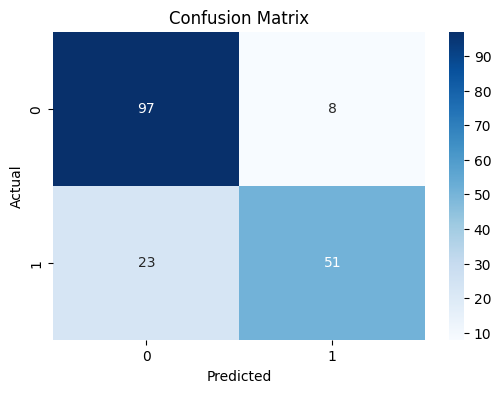

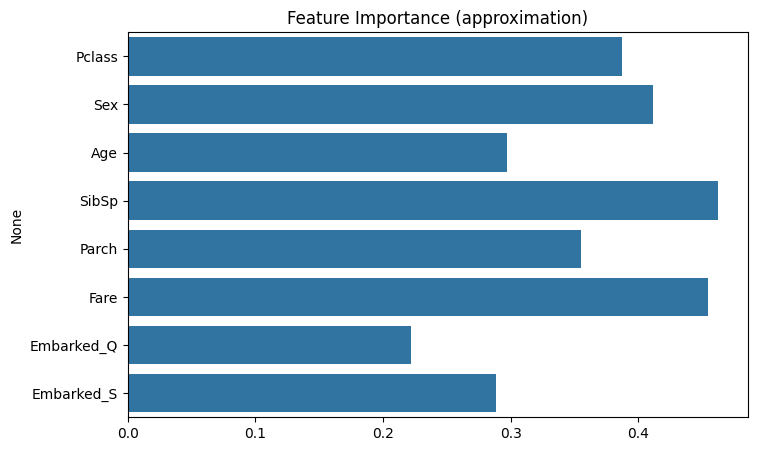

In [9]:
df = pd.read_csv(path + "titanic.csv")

#print(df.head())
print(df.info())
#print(df.columns)

df = df[['Survived','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]

df['Sex'] = df['Sex'].map({'male':0, 'female':1})
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

print(df.head())

X = df.drop('Survived', axis=1)
y = df['Survived']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

mlp = MLPClassifier(max_iter=500, random_state=42)


param_grid = {
    'hidden_layer_sizes': [(10,), (20,), (10,10), (20,10)],
    'activation': ['relu','tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001],
    'learning_rate': ['constant','adaptive']
}

grid_search = GridSearchCV(
    mlp,
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

best_model.fit(X_train, y_train)


y_pred = best_model.predict(X_test)



accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


feature_names = X.columns

importance = np.mean(np.abs(best_model.coefs_[0]), axis=1)

plt.figure(figsize=(8,5))

sns.barplot(x=importance, y=feature_names)

plt.title("Feature Importance (approximation)")
plt.show()



In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Задание 2. Алгоритм обратного распространения ошибки

---

В данном задании Вам нужно будет:
- дополнить класс **`Neuron()`** с функцией активации ReLU, чтобы в нём было запрограмировано обучение нейронной сети по методу обратного распространения ошибки (прямой и обратный проход по сети)

- обучить и протестировать этот класс на сгенерированных и реальных данных

In [ ]:
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd

In [ ]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

---

В данном случае мы решаем задачу бинарной классификации (2 класса: 1 или 0). Для простоты в качестве функции потерь возьмём квадратичную функцию потерь, хоть она и плохо показывает себя в задаче классификации.

$$
Loss(\hat{y}, y) = \frac{1}{n}\sum_{i=1}^{n} (\hat{y_i} - y_i)^2
$$  

Здесь $w \cdot X_i$ - скалярное произведение, а $\hat{y_i} = \sigma(w \cdot X_i ), а \  \sigma$- функция активации ($i$ -- номер объекта в выборке).

In [ ]:
def Loss(y_pred, y):
    y_pred = y_pred.reshape(-1, 1)
    y = np.array(y).reshape(-1, 1)
    return 0.5 * np.mean((y_pred - y) ** 2)

<h2 style="text-align: center;"><b>Нейрон с ReLU (Recitified Linear Unit)</b></h2>  

ReLU самая часто используемая (по крайней мере, пару лет назад) функция активации в нейронных сетях. Выглядит она очень просто:

\begin{equation*}
ReLU(x) =
 \begin{cases}
   0, &\text{$x \le 0$}\\
   x, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

Или по-другому:

$$
ReLU(x) = \max(0, x)
$$

В (свободном) переводе Rectified Linear Unit = "Усечённая линейная функция". Собственно, мы по сути просто не даём проходить отрицательным числам.

Производная здесь берётся как производная от кусочно-заданной функции, то есть на участках, где функция гладкая, и в нуле её доопредляют нулём:

\begin{equation*}
ReLU'(x) =
 \begin{cases}
   0, &\text{$x \le 0$}\\
   1, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

Подставим ReLu в Loss:

$$Loss(\hat{y}, y) = \frac{1}{2n}\sum_{i=1}^{n} (\hat{y_i} - y_i)^2 = \frac{1}{2n}\sum_{i=1}^{n} (ReLU(w \cdot X_i) - y_i)^2 = \begin{equation*}
\frac{1}{2n}\sum_{i=1}^{n}
 \begin{cases}
    y_i^2, &{w \cdot X_i \le 0}\\
   (w \cdot X_i - y_i)^2, &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}$$  

(помните, что $w \cdot X_i$ -- это число в данном случае (результат скалярного произведения двух векторов)).

Тогда формула для обновления весов при градиентном спуске будет такая (в матричном виде, рекмендуем вывести самим то, как это получается из формулы для одного объекта):

$$ \frac{\partial Loss}{\partial w} = \begin{equation*}
\frac{1}{n}\sum_{i=1}^{n}
 \begin{cases}
   0, &{w \cdot X_i \le 0}\\
   \frac{1}{n} X_i^T (w \cdot X_i - y), &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}$$

(напоминаем, что здесь $w \cdot X$ -- матричное произведение вектора $w$ (ведь вектор -- тоже матрица, не так ли?) и матрицы $X$ )

Почему в первом случае будет 0? Потому что в формулу $y_i^2$ не входят веса , а мы берём производную именно по весам $w$.

* Реализуйте ReLU и её производную:

In [ ]:
def relu(x):
    """ReLU-функция: max(0, x)"""
    return np.maximum(0, x)

In [10]:
def relu_derivative(x):
    """Производная ReLU: 1 для x>0, 0 иначе. x может быть вектор/матрица."""
    return (x > 0).astype(float)

SyntaxError: invalid syntax (3542404905.py, line 3)

Теперь нужно написать класс нейрон с ReLU:

In [ ]:
class NeuronReLU:
    def __init__(self, w=None, b=0):
        """
        :param: w -- вектор весов
        :param: b -- смещение
        """
        self.w = w
        self.b = b


    def activate(self, x):
        return relu(x)


    def forward_pass(self, X):
        """
        Рассчитывает ответ нейрона при предъявлении набора объектов
        :param: X -- матрица примеров размера (n, m), каждая строка - отдельный объект
        :return: вектор размера (n, 1) из нулей и единиц с ответами нейрона
        """
        n = X.shape[0]
        y_pred = np.zeros((n, 1))  # y_pred == y_predicted - предсказанные классы

        z = X @ self.w + self.b   # (n,m) @ (m,1) + число = (n,1)
        y_pred = self.activate(z) # применяем ReLU
        return y_pred


    def backward_pass(self, X, y, y_pred, learning_rate=0.005):
        """
        Обновляет значения весов нейрона в соответствии с этим объектом
        :param: X -- матрица входов размера (n, m)
                y -- вектор правильных ответов размера (n, 1)
                learning_rate - "скорость обучения" (символ alpha в формулах выше)
        В этом методе ничего возвращать не нужно, только правильно поменять веса
        с помощью градиентного спуска.
        """
        n = len(y)
        y = np.array(y).reshape(-1, 1)

        z = X @ self.w + self.b                        # считаем z заново (n,1)
        delta = (y_pred - y) * relu_derivative(z)      # ошибка × производная ReLU (n,1)

        grad_w = (X.T @ delta) / n                     # градиент по весам (m,1)
        grad_b = np.mean(delta)                        # градиент по смещению (число)

        self.w -= learning_rate * grad_w               # обновляем веса
        self.b -= learning_rate * grad_b               # обновляем bias



    def fit(self, X, y, num_epochs=300):
        """
        Спускаемся в минимум
        :param: X -- матрица объектов размера (n, m)
                y -- вектор правильных ответов размера (n, 1)
                num_epochs -- количество итераций обучения
        :return: losses -- вектор значений функции потерь
        """
        #self.w = np.zeros((X.shape[1], 1))  # столбец (m, 1)
        #self.b = 0  # смещение (число)
        Loss_values = []  # значения функции потерь на различных итерациях обновления весов

        for i in range(num_epochs):
            y_pred = self.forward_pass(X)
            Loss_values.append(Loss(y_pred, y))
            self.backward_pass(X,y, y_pred)

        return Loss_values

<h3 style="text-align: center;"><b>Тестирование нейрона с ReLU</b></h3>  

Здесь Вам нужно самим протестировать новый нейрон **на данных** ("Яблоки и Груши").
В итоге нужно вывести:
* график, на котором будет показано, как изменяется функция потерь $Loss$ в зависимости от числа итераций обучения
* график с раскраской выборки нейроном

***ПРИМЕЧАНИЕ***: пожалуйста, почаще проверяйте `.shape` у матриц и векторов: `self.w`, `X` и `y` внутри класса. Очень часто ошибка решается транспонированием или `.reshape()`'ом. Не забывайте проверять, что на что Вы умножаете и какой вектор (какой размер) хотите получить на выходе -- это очень помогает не запутаться.

** Проверка forward_pass()**

In [ ]:
w = np.array([1., 2.]).reshape(2, 1)
b = 2.
X = np.array([[1., 3.],
              [2., 4.],
              [-1., -3.2]])

neuron = NeuronReLU(w, b)
y_pred = neuron.forward_pass(X)
print ("y_pred = " + str(y_pred))

*Hint: "**-0.**" -- это просто ноль*

**Проверка backward_pass()**

In [ ]:
y = np.array([1, 0, 1]).reshape(3, 1)

In [ ]:
neuron.backward_pass(X, y, y_pred)

print ("w = " + str(neuron.w))
print ("b = " + str(neuron.b))

"Яблоки и Груши" (необходимо положить данные в папку `./data`):

In [ ]:
data = pd.read_csv("./data/apples_pears.csv")
plt.figure(figsize=(10, 8))
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=data['target'], cmap='rainbow')
plt.title('Яблоки и груши', fontsize=15)
plt.xlabel('симметричность', fontsize=14)
plt.ylabel('желтизна', fontsize=14)
plt.show();

In [ ]:
X = data.iloc[:,:2].values  # матрица объекты-признаки
y = data['target'].values.reshape((-1, 1))  # классы (столбец из нулей и единиц)

Выведите лосс при обучении нейрона с ReLU на этом датасете:

In [ ]:
%%time

neuron = NeuronReLU(w=np.random.rand(X.shape[1], 1), b=np.random.rand(1))
Loss_values = neuron.fit(X, y, num_epochs=10000)

plt.figure(figsize=(10, 8))
plt.plot(Loss_values)
plt.title('Функция потерь', fontsize=15)
plt.xlabel('номер итерации', fontsize=14)
plt.ylabel('$Loss(\hat{y}, y)$', fontsize=14)
plt.show()

Скорее всего сейчас у вас лосс -- это прямая линия, и вы видите, что веса не обновляются. Но почему?

Всё просто -- если присмотреться, то видно, что self.w и self.b иницилизируются нулями в начале `.fit()`-метода. Если расписать, как будет идти обновление, то видно, что из-за ReLU веса просто-напросто не будут обновляться, если начать с инициализации нулями.

Это -- одна из причин, по которой в нейронных сетях веса инициализируют случайными числами (обычно из отрезка [0, 1)).

Обучим нейрон, инициализировав случайно веса (поставьте 10000 итераций).

**!!! Закомментируйте инициализацию нулями в функции `.fit()` класса `NeuronReLU` !!!**

In [ ]:
%%time

neuron = NeuronReLU(w=np.random.rand(X.shape[1], 1), b=np.random.rand(1))
Loss_values = neuron.fit(X, y, num_epochs=10000)

plt.figure(figsize=(10, 8))
plt.plot(Loss_values)
plt.title('Функция потерь', fontsize=15)
plt.xlabel('номер итерации', fontsize=14)
plt.ylabel('$Loss(\hat{y}, y)$', fontsize=14)
plt.show()

Посмотрим, как предсказывает этот нейрон:

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=np.array(neuron.forward_pass(X) > 0.5).ravel(), cmap='spring')
plt.title('Яблоки и груши', fontsize=15)
plt.xlabel('симметричность', fontsize=14)
plt.ylabel('желтизна', fontsize=14)
plt.show();

Есть одна тенденция: пороговая функция активации и сигмоида (обычно всё же только сигмоида) чаще используются именно на **выходном слое** нейросети в задаче классификации -- ими предсказывают вероятности объектов принадлежать одному из классов, в то время как продвинутые функции активации (ReLU и те, что будут дальше) используются внутри нейросети, то есть в **скрытых слоях**.

Нужно понимать, что ReLU не может вернуть отрицательные числа.

**Плюсы ReLU:**

* дифференцируемая (с доопределением в нуле)
* нет проблемы затухающих градиентов, как в сигмоиде

**Возможные минусы ReLU:**

* не центрирована около 0 (может мешать скорости сходимости)
* зануляет все отрицательные входы, тем самым веса у занулённых нейронов могут часто *не обновляться*, эту проблему иногда называют *мёртвые нейроны*

С последней проблемой можно побороться, а именно:

<h2 style="text-align: center;"><b>Нейрон с LeakyReLU (Leaky Recitified Linear Unit)</b></h2>  

LeakyReLU очень слабо отличается от ReLU, но часто помогает сети обучаться быстрее, поскольку нет проблемы "мёртвых нейронов":

\begin{equation*}
LeakyReLU(x) =
 \begin{cases}
   \alpha x, &\text{$x \le 0$}\\
   x, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

где $\alpha$ -- маленькое число от 0 до 1.

Производная здесь берётся так же, но вместо нуля будет $\alpha$:

\begin{equation*}
LeakyReLU'(x) =
 \begin{cases}
   \alpha, &\text{$x \le 0$}\\
   1, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

Подставим LeakyReLu в Loss:

$$
Loss(\hat{y}, y) = \frac{1}{2n}\sum_{i=1}^{n} (\hat{y_i} - y_i)^2 = \frac{1}{2n}\sum_{i=1}^{n} (LeakyReLU(w \cdot X_i) - y_i)^2 =
\begin{equation*}
\frac{1}{2n}\sum_{i=1}^{n}
 \begin{cases}
   (\alpha \cdot w \cdot X_i - y_i)^2, &{w \cdot X_i \le 0}\\
   (w \cdot X_i - y_i)^2, &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}
$$  

Формула для обновления весов при градиентном спуске:

$$ \frac{\partial Loss}{\partial w} = \begin{equation*}
\frac{1}{n}\sum_{i=1}^{n}
 \begin{cases}
   \alpha X_i^T (w \cdot X_i - y), &{w \cdot X_i \le 0}\\
    X_i^T (w \cdot X_i - y), &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}$$


**Плюсы LeakyReLU:**

* дифференцируемая (с доопределнием в нуле)
* нет проблемы затухающих градиентов, как в сигмоиде
* нет проблемы "мёртвых нейронов", как в ReLU

**Возможные минусы LeakyReLU:**

* не центрирована около 0 (может мешать скорости сходимсти)
* немного не устойчива к "шуму" (см. лекции Стэнфорда)

<h2 style="text-align: center;"><b>Нейрон с ELU (Exponential Linear Unit)</a></b></h2>  

ELU -- не так давно предложенная (в 2015 году) функция активации, которая, как говорят авторы статьи, лучше LeakyReLU. Вот формула ELU:

\begin{equation*}
ELU(\alpha, x) =
 \begin{cases}
   \alpha (e^x - 1), &\text{$x \le 0$}\\
   x, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

где $\alpha$ -- маленькое число от 0 до 1.

Производная здесь берётся так же, но вместо нуля будет $\alpha$:

\begin{equation*}
ELU'(x) =
 \begin{cases}
   ELU(\alpha, x) + \alpha, &\text{$x \le 0$}\\
   1, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

Здесь в производной использован постой трюк -- сделано $- \alpha + \alpha$, чтобы вычислять было проще.

График этой функции:

<img src="http://p0.ifengimg.com/pmop/2017/0907/A004001DD141881BFD8AD62E5D31028C3BE3FAD1_size14_w446_h354.png" width=500 height=400>

Подставим ELu в Loss:

$$Loss(\hat{y}, y) = \frac{1}{2n}\sum_{i=1}^{n} (\hat{y_i} - y_i)^2 = \frac{1}{2n}\sum_{i=1}^{n} (ELU(\alpha, w \cdot X_i) - y_i)^2 = \begin{equation*}
\frac{1}{2n}\sum_{i=1}^{n}
 \begin{cases}
   (\alpha (e^{w \cdot X_i} - 1) - y_i)^2, &{w \cdot X_i \le 0}\\
   (w \cdot X_i - y_i)^2, &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}$$  

Здесь вам нужно выписать самим град спуск для весов. Брать производную "в лоб" некрасиво и неудобно. Нужно воспользоваться **правилом цепочки**, оно же **правило взятия производной сложной функции**:

$$ \frac{\partial Loss}{\partial w} = \begin{equation*}
\frac{1}{n}\sum_{i=1}^{n}
 \begin{cases}
   , &{w \cdot X_i \le 0}\\
   , &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}$$

**Плюсы ELU:**

* дифференцируемая (с доопределнием в нуле)
* нет проблемы затухающих градиентов, как в сигмоиде
* нет проблемы "мёртвых нейронов", как в ReLU
* более устойчива к "шуму" (см. лекции Стэнфорда)

**Возможные минусы ELU:**

* не очень хорошо центрирована около 0 (может мешать скорости сходимсти)
* вычислительно дольше, чем ReLU и LeakyReLU

---

И напоследок -- ещё интересные функции активации:

`SeLU()` и `Swish()`. Про них можно прочитать здесь: [SeLU](https://arxiv.org/pdf/1706.02515.pdf), [Swish](https://arxiv.org/pdf/1710.05941.pdf).

За функцию активации можно взять вообще почти любую функцию (которая, как вы полагаете, будет помогать обучению). Ещё больше функций активации вы можете [найти на википедии](https://en.wikipedia.org/wiki/Activation_function).

## Задание 3. Нейрон с различными функциями активации

Реализуйте предыдущее задание с помощью функций активации LeakyReLU и ELU. Сравните результаты

In [12]:
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

def leaky_relu_derivative(x, alpha=0.01):
    return np.where(x > 0, 1.0, alpha)

class NeuronLeakyReLU:
  def __init__(self, x = None, b = 0, alpha=0.01):
    self.w = w
    self.b = b
    self.alpha = alpha

  def activate(self, x):
    return leaky_relu(x, self.alpha)

  def forward_pass(self, x):
    n = X.shape[0]
    z = X @ self.w + self.b
    y_pred = self.activate(z)
    return y_pred

  def backward_pass(self, X, y, y_pred, learning_rate=0.005):
    n = len(y)
    y = np.array(y).reshape(-1, 1)
    z = X @ self.w + self.b
    delta = (y_pred - y) * leaky_relu_derivative(z, self.alpha)
    grad_w = (X.T @ delta) / n
    grad_b = np.mean(delta)

    self.w -= learning_rate * grad_w
    self.b -= learning_rate * grad_b

  def fit(self, X, y, num_epochs=300):
        Loss_values = []
        for i in range(num_epochs):
            y_pred = self.forward_pass(X)
            Loss_values.append(Loss(y_pred, y))
            self.backward_pass(X, y, y_pred)
        return Loss_values


In [13]:
def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

def elu_derivative(x, alpha=1.0):
    return np.where(x > 0, 1.0, elu(x, alpha) + alpha)

class NeuronELU:
    def __init__(self, w=None, b=0, alpha=1.0):
        self.w = w
        self.b = b
        self.alpha = alpha

    def activate(self, x):
        return elu(x, self.alpha)

    def forward_pass(self, X):
        n = X.shape[0]
        z = X @ self.w + self.b
        y_pred = self.activate(z)
        return y_pred

    def backward_pass(self, X, y, y_pred, learning_rate=0.005):
        n = len(y)
        y = np.array(y).reshape(-1, 1)
        z = X @ self.w + self.b
        delta = (y_pred - y) * elu_derivative(z, self.alpha)
        grad_w = (X.T @ delta) / n
        grad_b = np.mean(delta)
        self.w -= learning_rate * grad_w
        self.b -= learning_rate * grad_b

    def fit(self, X, y, num_epochs=300):
        Loss_values = []
        for i in range(num_epochs):
            y_pred = self.forward_pass(X)
            Loss_values.append(Loss(y_pred, y))
            self.backward_pass(X, y, y_pred)
        return Loss_values

SyntaxError: invalid syntax (3272993628.py, line 1)

In [ ]:
# Загружаем данные (если ещё не загружены)
# data = pd.read_csv("./data/apples_pears.csv")
X = data.iloc[:, :2].values
y = data['target'].values.reshape(-1, 1)

# Обучаем все три нейрона с одинаковыми начальными весами
w_init = np.random.rand(X.shape[1], 1)
b_init = np.random.rand(1)

neuron_relu    = NeuronReLU(w=w_init.copy(), b=b_init.copy())
neuron_leaky   = NeuronLeakyReLU(w=w_init.copy(), b=b_init.copy())
neuron_elu     = NeuronELU(w=w_init.copy(), b=b_init.copy())

loss_relu  = neuron_relu.fit(X, y, num_epochs=10000)
loss_leaky = neuron_leaky.fit(X, y, num_epochs=10000)
loss_elu   = neuron_elu.fit(X, y, num_epochs=10000)

# График сравнения Loss
plt.figure(figsize=(12, 6))
plt.plot(loss_relu,  label='ReLU',       color='blue')
plt.plot(loss_leaky, label='LeakyReLU',  color='orange')
plt.plot(loss_elu,   label='ELU',        color='green')
plt.title('Сравнение функций активации', fontsize=15)
plt.xlabel('Итерация', fontsize=13)
plt.ylabel('Loss', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# Итоговые значения Loss
print(f"ReLU      финальный Loss: {loss_relu[-1]:.6f}")
print(f"LeakyReLU финальный Loss: {loss_leaky[-1]:.6f}")
print(f"ELU       финальный Loss: {loss_elu[-1]:.6f}")

## Задание 4. Сравнение собственной реализации с библиотечной

Сравните качество работы Вашего персептрона (с любой функцией активации) и алгоритма из библиотеки `sklearn` на датасете с сайта [Kaggle](https://www.kaggle.com) - [Gender Recognition by Voice](https://www.kaggle.com/primaryobjects/voicegender). (Код можно взять из файла Introducing_Scikit_Learn). Можно доработать собственную реализацию персептрона, сделав из него многослойный персептрон.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Загрузка датасета (скачать с Kaggle: voice.csv)
data = pd.read_csv("voice.csv")

# Смотрим что внутри
print(data.head())
print(data.shape)
print(data['label'].value_counts())

# Целевую переменную переводим в числа: male=1, female=0
data['label'] = (data['label'] == 'male').astype(int)

# Разделяем признаки и целевую переменную
X = data.drop('label', axis=1).values   # (3168, 20)
y = data['label'].values.reshape(-1, 1) # (3168, 1)

# Делим на train/test — 80%/20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Масштабируем — ОБЯЗАТЕЛЬНО для нейросетей!
# StandardScaler: x_scaled = (x - mean) / std
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit только на train!
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Берём лучший нейрон из задания 3 (например LeakyReLU)
w_init = np.random.rand(X_train.shape[1], 1)
b_init = np.random.rand(1)

my_neuron = NeuronLeakyReLU(w=w_init.copy(), b=b_init.copy())
loss_values = my_neuron.fit(X_train, y_train, num_epochs=5000)

# График обучения
plt.figure(figsize=(10, 5))
plt.plot(loss_values, color='orange')
plt.title('Loss — свой нейрон (LeakyReLU)', fontsize=14)
plt.xlabel('Итерация', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True)
plt.show()

# Предсказания — порог 0.5: если выход > 0.5 → класс 1
y_pred_custom = (my_neuron.forward_pass(X_test) > 0.5).astype(int)

print("=== Свой нейрон ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_custom):.4f}")
print(classification_report(y_test, y_pred_custom, target_names=['female', 'male']))

# Обучаем MLPClassifier из sklearn
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # два скрытых слоя: 64 и 32 нейрона
    activation='relu',
    max_iter=1000,
    learning_rate_init=0.001,
    random_state=42
)
mlp.fit(X_train, y_train.ravel())  # .ravel() — из (n,1) в (n,)

y_pred_sklearn = mlp.predict(X_test)

print("=== sklearn MLP ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_sklearn):.4f}")
print(classification_report(y_test, y_pred_sklearn, target_names=['female', 'male']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Матрица ошибок — свой нейрон
cm1 = confusion_matrix(y_test, y_pred_custom)
ConfusionMatrixDisplay(cm1, display_labels=['female', 'male']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Свой нейрон (LeakyReLU)', fontsize=13)

# Матрица ошибок — sklearn
cm2 = confusion_matrix(y_test, y_pred_sklearn)
ConfusionMatrixDisplay(cm2, display_labels=['female', 'male']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('sklearn MLPClassifier', fontsize=13)

plt.tight_layout()
plt.show()

acc_custom  = accuracy_score(y_test, y_pred_custom)
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)

results = pd.DataFrame({
    'Модель':   ['Свой нейрон (LeakyReLU)', 'sklearn MLP'],
    'Accuracy': [f"{acc_custom:.4f}", f"{acc_sklearn:.4f}"]
})
print(results.to_string(index=False))

FileNotFoundError: [Errno 2] No such file or directory: 'voice.csv'

<h3 style="text-align: center;"><b>Полезные ссылки</b></h3>

0). Статья от Стэнфорда: http://cs231n.github.io/neural-networks-1/

1). Хорошая статья про функции активации: https://www.jeremyjordan.me/neural-networks-activation-functions/

2). [Видео от Siraj Raval](https://www.youtube.com/watch?v=-7scQpLossT7uo)

3). Современная статья про функции активации. Теперь на хайпе активация $swish(x) = x\sigma (\beta x)$: https://arxiv.org/pdf/1710.05941.pdf (кстати, при её поиске в некоторой степени использовался neural architecture search)

4). SeLU имеет очень интересные, доказанные с помощью теории вероятностей свойства: https://arxiv.org/pdf/1706.02515.pdf (да, в этой статье 102 страницы)

5). [Список функций активации из википедии](https://en.wikipedia.org/wiki/Activation_function)